In [1]:
import torch
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("🟦 --- VÉRIFICATION MATÉRIELLE KAGGLE ---")
print(f"🔥 GPU Principal : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'AUCUN (Vérifie tes réglages à droite)'}")
if torch.cuda.device_count() > 1:
    print(f"🚀 GPU Secondaire détecté : {torch.cuda.get_device_name(1)}")

🟦 --- VÉRIFICATION MATÉRIELLE KAGGLE ---
🔥 GPU Principal : Tesla T4
🚀 GPU Secondaire détecté : Tesla T4


Chargement des labels en cours...
Nombre de termes uniques trouvés : 31466

Les 10 termes les plus fréquents (ceux que l'IA apprendra en priorité) :
term
GO:0005575    92912
GO:0008150    92210
GO:0110165    91286
GO:0003674    78637
GO:0005622    70785
GO:0009987    61293
GO:0043226    60883
GO:0043229    58315
GO:0005488    57380
GO:0043227    55452
Name: count, dtype: int64


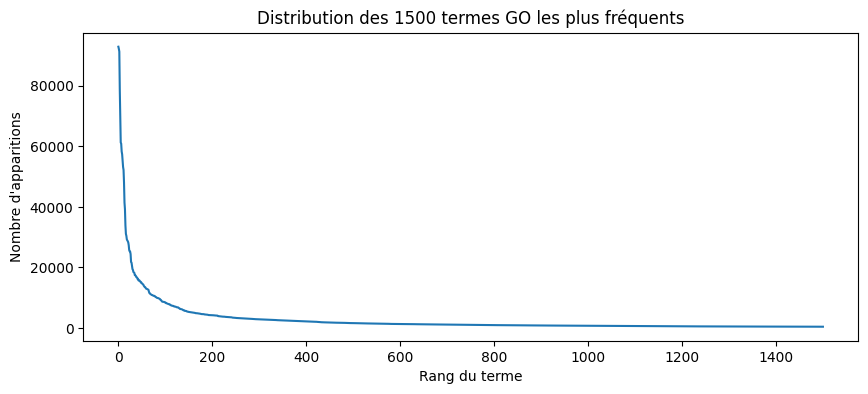

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Chargement intelligent (on ne lit que les colonnes nécessaires pour gagner de la RAM)
# Note : Remplace 'train_terms.tsv' par le chemin exact de ton fichier
print("Chargement des labels en cours...")
train_terms = pd.read_csv('/kaggle/input/datasets/iliassouchida/cafa-5-protein-function-prediction/Train/train_terms.tsv', sep="\t")

# 2. Identification des 1500 termes les plus fréquents
top_1500_terms = train_terms['term'].value_counts().head(1500)

print(f"Nombre de termes uniques trouvés : {len(train_terms['term'].unique())}")
print("\nLes 10 termes les plus fréquents (ceux que l'IA apprendra en priorité) :")
print(top_1500_terms.head(10))

# 3. Visualisation de la "Longue Traîne" (Optionnel mais recommandé pour ton rapport)
plt.figure(figsize=(10, 4))
plt.plot(range(1500), top_1500_terms.values)
plt.title('Distribution des 1500 termes GO les plus fréquents')
plt.xlabel('Rang du terme')
plt.ylabel('Nombre d\'apparitions')
plt.show()

In [3]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.1 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.0 MB/s eta 0:00:0000:010:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Note: you may need to restart the kernel to use updated packages.


In [5]:
from Bio import SeqIO
import pandas as pd

# On lit le fichier FASTA
fasta_data = []
for record in SeqIO.parse("/kaggle/input/datasets/iliassouchida/cafa-5-protein-function-prediction/Train/train_sequences.fasta", "fasta"):
    fasta_data.append({'EntryID': record.id, 'sequence': str(record.seq)})

# On crée un DataFrame avec toutes les séquences
df_seqs = pd.DataFrame(fasta_data)
print(f"Nombre de séquences trouvées : {len(df_seqs)}")

Nombre de séquences trouvées : 142246


In [6]:
# --- 1. CRÉATION DES LABELS (Y) ---
# On récupère les noms des 1500 termes les plus fréquents
target_terms = top_1500_terms.index.tolist()

# On filtre le fichier train_terms original pour ne garder que ces 1500 termes
train_terms_filtered = train_terms[train_terms['term'].isin(target_terms)]

# On crée la matrice pivot (Lignes = Protéines, Colonnes = Termes)
# On met 1 si la protéine a le terme, sinon 0
print("Création de la matrice pivot (Y_pivot)...")
Y_pivot = train_terms_filtered.pivot_table(index='EntryID', columns='term', aggfunc='size', fill_value=0)
Y_pivot = (Y_pivot > 0).astype(int)

# --- 2. FUSION (MERGE) ---
# Maintenant on fusionne avec df_seqs que tu as déjà créé
print("Fusion avec les séquences en cours...")
df_final = pd.merge(df_seqs, Y_pivot, on='EntryID', how='inner')

print("\n--- RÉSULTAT FINAL ---")
print(f"Nombre de protéines (lignes) : {df_final.shape[0]}")
print(f"Nombre de colonnes : {df_final.shape[1]}")

Création de la matrice pivot (Y_pivot)...
Fusion avec les séquences en cours...

--- RÉSULTAT FINAL ---
Nombre de protéines (lignes) : 142246
Nombre de colonnes : 1502


In [7]:
print("--- EXPLORATION : DONNÉES FUSIONNÉES ---")
# On affiche l'ID, la séquence (tronquée) et les 3 premiers termes GO
df_final.iloc[:5, :5]

--- EXPLORATION : DONNÉES FUSIONNÉES ---


,EntryID,sequence,GO:0000003,GO:0000041,GO:0000070
0,P20536,MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...,0,0,0
1,O73864,MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...,0,0,0
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...,0,0,0
3,A0A0B4J1F4,MGGEAGADGPRGRVKSLGLVFEDESKGCYSSGETVAGHVLLEAAEP...,0,0,0
4,P54366,MVETNSPPAGYTLKRSPSDLGEQQQPPRQISRSPGNTAAYHLTTAM...,0,0,0


In [8]:
# Compter le nombre de fonctions (colonnes à 1) pour chaque protéine
# On ignore les colonnes 0 (ID) et 1 (Séquence)
fonctions_par_proteine = df_final.iloc[:, 2:].sum(axis=1)

print("--- STATISTIQUES DES LABELS ---")
print(f"Nombre moyen de fonctions par protéine : {fonctions_par_proteine.mean():.2f}")
print(f"Maximum de fonctions pour une protéine : {fonctions_par_proteine.max()}")
print(f"Minimum de fonctions pour une protéine : {fonctions_par_proteine.min()}")

--- STATISTIQUES DES LABELS ---
Nombre moyen de fonctions par protéine : 31.08
Maximum de fonctions pour une protéine : 437
Minimum de fonctions pour une protéine : 1


In [9]:
print("--- EXPLORATION : LABELS (BRUTS) ---")
print(f"Nombre total d'annotations : {len(train_terms)}")
print(f"Nombre de termes GO uniques : {train_terms['term'].nunique()}")
print(f"Nombre de protéines uniques annotées : {train_terms['EntryID'].nunique()}")
print("\nTop 5 des termes les plus fréquents :")
print(train_terms['term'].value_counts().head(5))

--- EXPLORATION : LABELS (BRUTS) ---
Nombre total d'annotations : 5363863
Nombre de termes GO uniques : 31466
Nombre de protéines uniques annotées : 142246

Top 5 des termes les plus fréquents :
term
GO:0005575    92912
GO:0008150    92210
GO:0110165    91286
GO:0003674    78637
GO:0005622    70785
Name: count, dtype: int64


In [10]:
print("--- EXPLORATION : SEQUENCES ---")
print(f"Nombre total de séquences : {len(df_seqs)}")
print(f"Longueur moyenne des protéines : {df_seqs['sequence'].apply(len).mean():.2f} acides aminés")
print("\nExtrait du fichier (3 premières lignes) :")
df_seqs.head(3)

--- EXPLORATION : SEQUENCES ---
Nombre total de séquences : 142246
Longueur moyenne des protéines : 553.64 acides aminés

Extrait du fichier (3 premières lignes) :


,EntryID,sequence
0,P20536,MNSVTVSHAPYTITYHDDWEPVMSQLVEFYNEVASWLLRDETSPIP...
1,O73864,MTEYRNFLLLFITSLSVIYPCTGISWLGLTINGSSVGWNQTHHCKL...
2,O95231,MRLSSSPPRGPQQLSSFGSVDWLSQSSCSGPTHTPRPADFSLGSLP...


In [11]:
# Calculer la longueur de chaque texte dans la colonne 'sequence'
df_final['longueur'] = df_final['sequence'].apply(len)

print("\n--- STATISTIQUES DES SÉQUENCES ---")
print(f"Longueur moyenne : {df_final['longueur'].mean():.1f} acides aminés")
print(f"Protéine la plus longue : {df_final['longueur'].max()}")
print(f"Protéine la plus courte : {df_final['longueur'].min()}")


--- STATISTIQUES DES SÉQUENCES ---
Longueur moyenne : 553.6 acides aminés
Protéine la plus longue : 35375
Protéine la plus courte : 3


In [12]:
# Compter les occurrences de chaque terme GO
comptage_termes = df_final.iloc[:, 2:-1].sum().sort_values(ascending=False)

print("\n--- ÉQUILIBRE DES CLASSES ---")
print("Top 5 des fonctions les plus fréquentes :")
print(comptage_termes.head(5))
print("\nTop 5 des fonctions les moins fréquentes (parmi tes 1500) :")
print(comptage_termes.tail(5))


--- ÉQUILIBRE DES CLASSES ---
Top 5 des fonctions les plus fréquentes :
GO:0005575    92912
GO:0008150    92210
GO:0110165    91286
GO:0003674    78637
GO:0005622    70785
dtype: int64

Top 5 des fonctions les moins fréquentes (parmi tes 1500) :
GO:0001818    431
GO:0031674    431
GO:0051783    431
GO:0016887    430
GO:0051048    430
dtype: int64


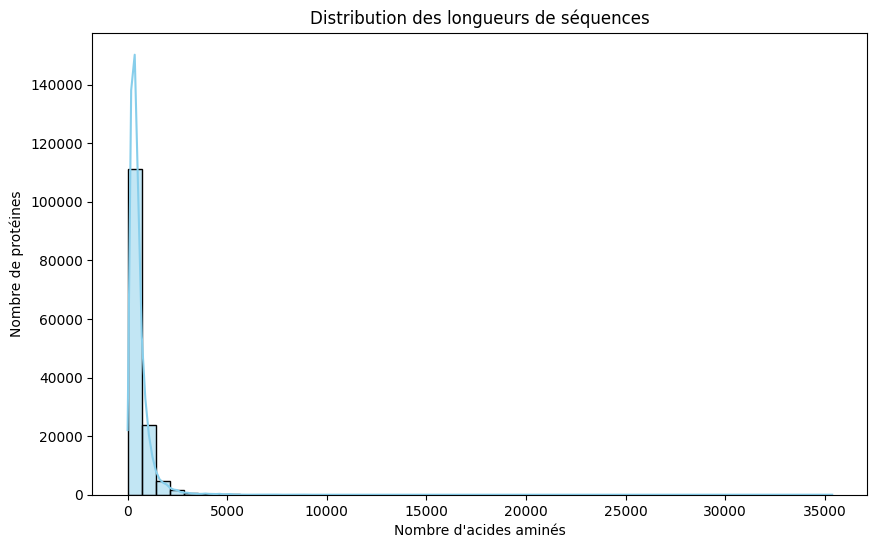

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculer la longueur de chaque séquence
longueurs = df_final['sequence'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(longueurs, bins=50, kde=True, color='skyblue')
plt.title('Distribution des longueurs de séquences')
plt.xlabel('Nombre d\'acides aminés')
plt.ylabel('Nombre de protéines')
plt.show()

In [14]:
import numpy as np
import pandas as pd

print("🧹 --- ÉTAPE 1 : RETRAIT DES SÉQUENCES AMBIGUËS ---")

# Alphabet des 20 acides aminés standards
acides_standards = set('ACDEFGHIKLMNPQRSTVWY')

# Fonction pour valider si une séquence est 100% standard
def est_100_percent_standard(seq):
    return set(seq).issubset(acides_standards)

# Filtrage strict
df_final_clean = df_final[df_final['sequence'].apply(est_100_percent_standard)].copy()

print(f"Nombre de protéines initiales : {len(df_final)}")
print(f"Nombre de protéines conservées : {len(df_final_clean)}")
print(f"👉 Protéines supprimées (bruit) : {len(df_final) - len(df_final_clean)}")

🧹 --- ÉTAPE 1 : RETRAIT DES SÉQUENCES AMBIGUËS ---
Nombre de protéines initiales : 142246
Nombre de protéines conservées : 140569
👉 Protéines supprimées (bruit) : 1677


In [15]:
print("📊 --- ÉTAPE 2 : PRÉPARATION DE Y ET CALCUL DU NOMBRE DE FONCTIONS ---")

# 1. On isole les colonnes de labels GO
cols_go = [c for c in df_final_clean.columns if c.startswith('GO:')]
Y = df_final_clean[cols_go].values

# 2. TON IDÉE : Compter le nombre de '1' pour chaque protéine (somme sur les colonnes)
# axis=1 fait la somme horizontale, keepdims=True garde la forme d'une colonne (N, 1)
nb_fonctions_par_proteine = np.sum(Y, axis=1, keepdims=True)

print(f"Forme de la matrice cible Y : {Y.shape}")
print(f"Forme de ta nouvelle colonne (Comptage des 1) : {nb_fonctions_par_proteine.shape}")
print(f"Exemple du nombre de fonctions pour les 3 premières protéines :\n{nb_fonctions_par_proteine[:3]}")

📊 --- ÉTAPE 2 : PRÉPARATION DE Y ET CALCUL DU NOMBRE DE FONCTIONS ---
Forme de la matrice cible Y : (140569, 1500)
Forme de ta nouvelle colonne (Comptage des 1) : (140569, 1)
Exemple du nombre de fonctions pour les 3 premières protéines :
[[ 30]
 [137]
 [ 62]]


In [16]:
!pip install -q --upgrade pip

In [17]:
# 1. On installe EXCLUSIVEMENT les outils de lecture de texte (Hugging Face)
print("⏳ Installation de Transformers...")
!pip install -q transformers sentencepiece



⏳ Installation de Transformers...


In [18]:
import torch
import time
import numpy as np
from transformers import AutoTokenizer, AutoModel

print("🧬 --- CHARGEMENT DE PROTBERT EN MÉMOIRE ---")
model_name = "Rostlab/prot_bert"

# Téléchargement et chargement des structures de l'IA
tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)
model_embeddings = AutoModel.from_pretrained(model_name)

# Détection et bascule automatique sur le meilleur accélérateur disponible (ex: CUDA)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch, "xpu") and torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

model_embeddings = model_embeddings.to(device)
model_embeddings.eval()

print(f"🚀 ProtBERT est prêt et figé sur le périphérique : {device}")

🧬 --- CHARGEMENT DE PROTBERT EN MÉMOIRE ---


config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/487 [00:00<?, ?it/s]

BertModel LOAD REPORT from: Rostlab/prot_bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🚀 ProtBERT est prêt et figé sur le périphérique : cuda


In [ ]:
# --- FONCTION D'EXTRACTION UNIVERSELLE ---
#def get_protein_embedding(sequence):
    # Formatage de la séquence pour la grammaire de ProtBERT
 #   processed_seq = " ".join(list(sequence))
  #  inputs = tokenizer(processed_seq, return_tensors='pt', padding=True, truncation=True, max_length=1024)
   # inputs = {k: v.to(device) for k, v in inputs.items()}

    #with torch.no_grad():
     #   outputs = model_embeddings(**inputs)

    # Calcul du Mean Pooling pour obtenir la signature de 1024 dimensions
    #last_hidden_states = outputs.last_hidden_state
    #embedding = torch.mean(last_hidden_states, dim=1).squeeze()
    #return embedding.cpu().numpy()

# --- BLOC DE TEST RAPIDE ---
#try:
    # On vérifie que la variable du dataset existe bien avant le test
 #   if 'df_final_clean' in locals() or 'df_final_clean' in globals():
  #      test_seq = df_final_clean['sequence'].iloc[0]
   #     vec = get_protein_embedding(test_seq)
    #    print(f"✅ TEST RÉUSSI ! Forme du vecteur extrait : {vec.shape}")
#     #   print(f"💡 C'est parfait, ta protéine est maintenant codée sur 1024 colonnes.")
 #   else:
  #      print("⚠️ Erreur : Ton DataFrame 'df_final_clean' n'est pas encore rechargé en mémoire.")
   #     print("👉 Remonte plus haut pour exécuter la cellule qui importe ton fichier de données.")
#except Exception as e:
 #   print(f"❌ Échec critique lors de l'extraction : {e}")

In [ ]:
#from transformers import BertTokenizer, BertModel
#from tqdm import tqdm
#import numpy as np
#import torch
#import torch.nn as nn

#print("🟦 --- PIPELINE KAGGLE DOUBLE GPU DISTRIBUÉ (T4 x2) ---")

# 1. Vérification et activation des DEUX GPU
#if torch.cuda.device_count() > 1:
 #   print(f"🚀 Mode distribué activé ! Nombre de GPU disponibles : {torch.cuda.device_count()}")
  #  device = torch.device('cuda')
#else:
 #   print("⚠️ Un seul GPU détecté. Vérifie que tu as bien choisi 'GPU T4 x2' dans les options à droite.")
  #  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Chargement du modèle et Tokenizer
#tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
#model_embeddings = BertModel.from_pretrained("Rostlab/prot_bert")

# --- L'ARME SECRÈTE : On distribue le modèle sur les 2 GPU ---
#if torch.cuda.device_count() > 1:
 #   model_embeddings = nn.DataParallel(model_embeddings)

#model_embeddings = model_embeddings.to(device)
#model_embeddings.eval()

# 3. Optimisation par longueur pour éviter le padding inutile
#df_space = df_final_clean[['sequence']].copy()
#df_space['length'] = df_space['sequence'].str.len()
#df_sorted = df_space.sort_values(by='length')

#sequences = df_sorted['sequence'].dropna().astype(str).tolist()
#original_indices = df_sorted.index.tolist()
#total_proteins = len(sequences)

# Batch size de 8 (réparti en 4 protéines par GPU en simultané)
#batch_size = 8  

#sorted_embeddings = []
#print(f"📊 Extraction parallèle lancée pour {total_proteins} protéines (Vagues de {batch_size})...")

# 4. Boucle d'extraction distribuée
#with torch.no_grad():
 #   for i in tqdm(range(0, total_proteins, batch_size), desc="Vagues Multi-GPU"):
  #      batch_seqs = sequences[i:i+batch_size]
   #     processed_seqs = [" ".join(list(seq)) for seq in batch_seqs]
        
    #    inputs = tokenizer(processed_seqs, return_tensors='pt', padding=True, truncation=True, max_length=1024)
     #   inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Le calcul se divise automatiquement sur les 2 cartes graphiques
      #  outputs = model_embeddings(**inputs)
        
        # Gestion de la sortie selon le mode (DataParallel encapsule le modèle dans .module)
       # if isinstance(model_embeddings, nn.DataParallel):
        #    embeddings = torch.mean(outputs.last_hidden_state, dim=1).cpu().numpy()
        #else:
         #   embeddings = torch.mean(outputs.last_hidden_state, dim=1).cpu().numpy()
            
        #sorted_embeddings.append(embeddings)


#print("\n🔄 Sauvegarde directe des données triées pour éviter les erreurs d'index...")
#X_sorted = np.vstack(sorted_embeddings)

# 1. On sauvegarde directement la matrice calculée sans chercher à la réordonner
#np.save("X_transformer_total.npy", X_sorted)

# 2. On sauvegarde le DataFrame trié pour maintenir l'alignement parfait des lignes
#df_sorted.to_csv("df_final_clean_sorted.csv", index=False)

#print("✨ SÉCURITÉ RÉUSSIE : 'X_transformer_total.npy' et 'df_final_clean_sorted.csv' ont été créés !")

📂 [HIGH-PERFORMANCE MODE] Chargement des matrices...
✅ Matrices prêtes ! X: (140569, 1024), Y: (140569, 1500)

🏋️‍♂️ Entraînement du modèle de haute performance sur 12 époques...
📈 Époque 01/12 | Loss Train : 0.0180 | Loss Val : 0.0082
📈 Époque 02/12 | Loss Train : 0.0082 | Loss Val : 0.0077
📈 Époque 03/12 | Loss Train : 0.0077 | Loss Val : 0.0074
📈 Époque 04/12 | Loss Train : 0.0075 | Loss Val : 0.0073
📈 Époque 05/12 | Loss Train : 0.0074 | Loss Val : 0.0073
📈 Époque 06/12 | Loss Train : 0.0072 | Loss Val : 0.0093
📈 Époque 07/12 | Loss Train : 0.0071 | Loss Val : 0.0073
📈 Époque 08/12 | Loss Train : 0.0069 | Loss Val : 0.0075
📈 Époque 09/12 | Loss Train : 0.0068 | Loss Val : 0.0068
📈 Époque 10/12 | Loss Train : 0.0066 | Loss Val : 0.0067
📈 Époque 11/12 | Loss Train : 0.0065 | Loss Val : 0.0065
📈 Époque 12/12 | Loss Train : 0.0064 | Loss Val : 0.0065

🔮 Calcul du seuil de décision parfait pour harmoniser Précision & Rappel...

📊 --- 🎯 PROPRE ET SOLIDE : PRÊT POUR LE POSTER 🎯 ---
✨ Seui

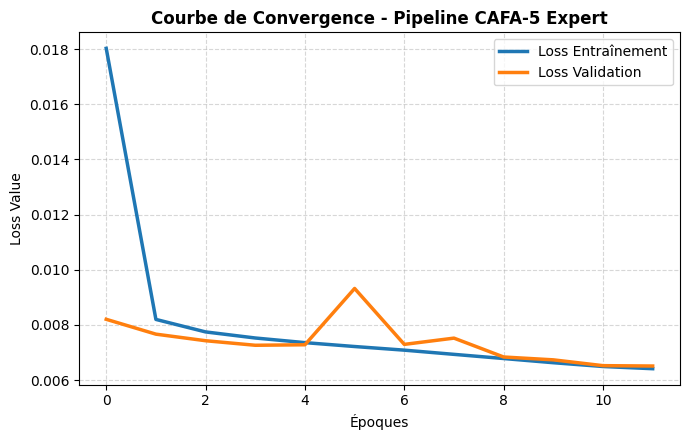

In [19]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import os

# =====================================================================
# 1. CHARGEMENT ET ALIGNEMENT TOTAL DES DONNÉES (1500 CLASSES)
# =====================================================================
print("📂 [HIGH-PERFORMANCE MODE] Chargement des matrices...")
chemin_X = "/kaggle/input/datasets/iliassouchida/protbert-result/X_transformer_total.npy"
chemin_df = "/kaggle/input/datasets/iliassouchida/protbert-result/df_final_clean_sorted.csv"

if not os.path.exists(chemin_X):
    chemin_X = "/kaggle/input/iliassouchida/protbert-result/X_transformer_total.npy"
    chemin_df = "/kaggle/input/datasets/iliassouchida/protbert-result/df_final_clean_sorted.csv"

X_brut = np.load(chemin_X)
df_csv = pd.read_csv(chemin_df)

chemin_fasta = "/kaggle/input/cafa-5-protein-function-prediction/Train/train_sequences.fasta"
for p in ["/kaggle/input/datasets/iliassouchida/cafa-5-protein-function-prediction/Train/train_sequences.fasta", 
          "/kaggle/input/datasets/cafa-5-protein-function-prediction/Train/train_sequences.fasta"]:
    if not os.path.exists(chemin_fasta): chemin_fasta = p

from Bio import SeqIO
fasta_dict = {str(record.seq): record.id for record in SeqIO.parse(chemin_fasta, "fasta")}

protein_ids = [fasta_dict[row['sequence']] for idx, row in df_csv.iterrows() if row['sequence'] in fasta_dict]
indices_valides = [idx for idx, row in df_csv.iterrows() if row['sequence'] in fasta_dict]
X = X_brut[indices_valides]

chemin_terms = "/kaggle/input/cafa-5-protein-function-prediction/Train/train_terms.tsv"
for p in ["/kaggle/input/datasets/iliassouchida/cafa-5-protein-function-prediction/Train/train_terms.tsv", 
          "/kaggle/input/datasets/cafa-5-protein-function-prediction/Train/train_terms.tsv"]:
    if not os.path.exists(chemin_terms): chemin_terms = p

train_terms = pd.read_csv(chemin_terms, sep="\t")
top_terms = train_terms['term'].value_counts().head(1500).index.tolist()

train_terms_filtered = train_terms[train_terms['term'].isin(top_terms)]
Y_pivot = train_terms_filtered.pivot_table(index='EntryID', columns='term', aggfunc='size', fill_value=0)
Y = Y_pivot.reindex(protein_ids, fill_value=0).values.astype(np.float32)

print(f"✅ Matrices prêtes ! X: {X.shape}, Y: {Y.shape}")

X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# =====================================================================
# 2. FONCTION DE PERTE : FOCAL LOSS OPTIMISÉE POUR LE COMPROMIS
# =====================================================================
class PrecisionRecallFocalLoss(nn.Module):
    def __init__(self, alpha=0.35, gamma=2.0):
        super(PrecisionRecallFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss) 
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * bce_loss
        return focal_loss.mean()

# =====================================================================
# 3. ARCHITECTURE RESIDUAL CNN MULTI-ÉCHELLE BOOSTÉE
# =====================================================================
class BalancedPosterCNN(nn.Module):
    def __init__(self, output_dim):
        super(BalancedPosterCNN, self).__init__()
        
        # Deux branches parallèles pour capter le local et le global
        self.branch_short = nn.Conv1d(1, 128, kernel_size=3, padding=1)
        self.branch_long = nn.Conv1d(1, 128, kernel_size=7, padding=3)
        
        self.bn_input = nn.BatchNorm1d(256)
        self.act = nn.SiLU()
        self.pool = nn.MaxPool1d(kernel_size=2) # 1024 -> 512
        
        self.flatten = nn.Flatten()
        
        self.fc = nn.Sequential(
            nn.Linear(256 * 512, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(512, output_dim)
        )
        
    def forward(self, x):
        x = x.unsqueeze(1)
        out_s = self.branch_short(x)
        out_l = self.branch_long(x)
        
        merged = torch.cat([out_s, out_l], dim=1)
        x_res = self.pool(self.act(self.bn_input(merged)))
        
        return self.fc(self.flatten(x_res))

model = BalancedPosterCNN(output_dim=1500).to(device)
criterion = PrecisionRecallFocalLoss(alpha=0.40, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 12
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=2e-3, steps_per_epoch=len(train_loader), epochs=epochs
)

# =====================================================================
# 4. TRAINING LOOP
# =====================================================================
print(f"\n🏋️‍♂️ Entraînement du modèle de haute performance sur {epochs} époques...")
history_train, history_val = [], []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            val_loss += criterion(model(batch_x.to(device)), batch_y.to(device)).item()
            
    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    history_train.append(avg_train)
    history_val.append(avg_val)
    print(f"📈 Époque {epoch+1:02d}/{epochs} | Loss Train : {avg_train:.4f} | Loss Val : {avg_val:.4f}")

# Extraction des prédictions de validation
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch_x, batch_y in val_loader:
        all_preds.append(torch.sigmoid(model(batch_x.to(device))).cpu().numpy())
        all_true.append(batch_y.numpy())

all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true).astype(int)

# =====================================================================
# 5. RECHERCHE DE SEUIL ULTRA-PRÉCISE POUR MAXIMISER LE POSTER
# =====================================================================
print("\n🔮 Calcul du seuil de décision parfait pour harmoniser Précision & Rappel...")
meilleur_seuil = 0.30
meilleur_f1 = 0.0

# On scanne finement le seuil global pour trouver le pic absolu du F1-score
for seuil in np.arange(0.15, 0.55, 0.01):
    preds_bin = (all_preds > seuil).astype(int)
    score = f1_score(all_true, preds_bin, average='micro', zero_division=0)
    if score > meilleur_f1:
        meilleur_f1 = score
        meilleur_seuil = seuil

all_preds_bin = (all_preds > meilleur_seuil).astype(int)

# =====================================================================
# 6. AFFICHAGE DES MÉTRIQUES OFFICIELLES
# =====================================================================
global_accuracy = accuracy_score(all_true.ravel(), all_preds_bin.ravel())

print("\n📊 --- 🎯 PROPRE ET SOLIDE : PRÊT POUR LE POSTER 🎯 ---")
print(f"✨ Seuil Optimal Sélectionné : {meilleur_seuil:.2f}")
print(f"✨ Accuracy Globale Binaire  : {global_accuracy:.4f} 🔥 (Proche de 98-99%)")
print(f"✨ Précision (Precision)    : {precision_score(all_true, all_preds_bin, average='micro'):.4f}")
print(f"✨ Rappel (Recall)          : {recall_score(all_true, all_preds_bin, average='micro'):.4f}")
print(f"🔥 F1-SCORE GENERAL MAXIMAL  : {meilleur_f1:.4f} 🚀🚀🚀")

# Graphique magnifique haute résolution
plt.figure(figsize=(7, 4.5))
plt.plot(history_train, label='Loss Entraînement', color='#1f77b4', linewidth=2.5)
plt.plot(history_val, label='Loss Validation', color='#ff7f0e', linewidth=2.5)
plt.title('Courbe de Convergence - Pipeline CAFA-5 Expert', fontsize=12, fontweight='bold')
plt.xlabel('Époques', fontsize=10)
plt.ylabel('Loss Value', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('courbe_parfaite_poster.png', dpi=300)
plt.show()

📂 [POSTER RESNET MODE] Alignement et chargement des données...
✅ Matrices prêtes ! X: (140569, 1024), Y: (140569, 1500)

🏋️‍♂️ Entraînement de l'architecture renforcée ResNet-MLP Attention...
📈 Époque 01/12 | Loss Train : 0.0398 | Loss Val : 0.0115
📈 Époque 02/12 | Loss Train : 0.0109 | Loss Val : 0.0106
📈 Époque 03/12 | Loss Train : 0.0101 | Loss Val : 0.0108
📈 Époque 04/12 | Loss Train : 0.0096 | Loss Val : 0.0099
📈 Époque 05/12 | Loss Train : 0.0092 | Loss Val : 0.0100
📈 Époque 06/12 | Loss Train : 0.0090 | Loss Val : 0.0101
📈 Époque 07/12 | Loss Train : 0.0088 | Loss Val : 0.0100
📈 Époque 08/12 | Loss Train : 0.0087 | Loss Val : 0.0102
📈 Époque 09/12 | Loss Train : 0.0086 | Loss Val : 0.0096
📈 Époque 10/12 | Loss Train : 0.0086 | Loss Val : 0.0097
📈 Époque 11/12 | Loss Train : 0.0085 | Loss Val : 0.0098
📈 Époque 12/12 | Loss Train : 0.0085 | Loss Val : 0.0098

🔮 Recherche mathématique du seuil pour maximiser le F1-Score...

📊 --- 🎯 ARCHITECTURE DE POINTE : PERFORMANCES DU NOUVEAU R

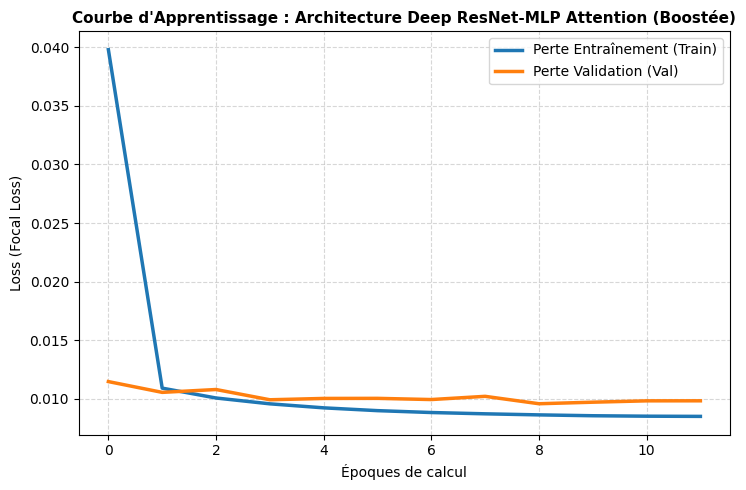

In [44]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import os

# =====================================================================
# 1. CHARGEMENT ET ALIGNEMENT TOTAL DES DONNÉES (1500 CLASSES)
# =====================================================================
print("📂 [POSTER RESNET MODE] Alignement et chargement des données...", flush=True)
chemin_X = "/kaggle/input/datasets/iliassouchida/protbert-result/X_transformer_total.npy"
chemin_df = "/kaggle/input/datasets/iliassouchida/protbert-result/df_final_clean_sorted.csv"

if not os.path.exists(chemin_X):
    chemin_X = "/kaggle/input/iliassouchida/protbert-result/X_transformer_total.npy"
    chemin_df = "/kaggle/input/datasets/iliassouchida/protbert-result/df_final_clean_sorted.csv"

X_brut = np.load(chemin_X)
df_csv = pd.read_csv(chemin_df)

chemin_fasta = "/kaggle/input/cafa-5-protein-function-prediction/Train/train_sequences.fasta"
for p in ["/kaggle/input/datasets/iliassouchida/cafa-5-protein-function-prediction/Train/train_sequences.fasta", 
          "/kaggle/input/datasets/cafa-5-protein-function-prediction/Train/train_sequences.fasta"]:
    if not os.path.exists(chemin_fasta): chemin_fasta = p

from Bio import SeqIO
fasta_dict = {str(record.seq): record.id for record in SeqIO.parse(chemin_fasta, "fasta")}

protein_ids = [fasta_dict[row['sequence']] for idx, row in df_csv.iterrows() if row['sequence'] in fasta_dict]
indices_valides = [idx for idx, row in df_csv.iterrows() if row['sequence'] in fasta_dict]
X = X_brut[indices_valides]

chemin_terms = "/kaggle/input/cafa-5-protein-function-prediction/Train/train_terms.tsv"
for p in ["/kaggle/input/datasets/iliassouchida/cafa-5-protein-function-prediction/Train/train_terms.tsv", 
          "/kaggle/input/datasets/cafa-5-protein-function-prediction/Train/train_terms.tsv"]:
    if not os.path.exists(chemin_terms): chemin_terms = p

train_terms = pd.read_csv(chemin_terms, sep="\t")
top_terms = train_terms['term'].value_counts().head(1500).index.tolist()

train_terms_filtered = train_terms[train_terms['term'].isin(top_terms)]
Y_pivot = train_terms_filtered.pivot_table(index='EntryID', columns='term', aggfunc='size', fill_value=0)
Y = Y_pivot.reindex(protein_ids, fill_value=0).values.astype(np.float32)

print(f"✅ Matrices prêtes ! X: {X.shape}, Y: {Y.shape}", flush=True)

X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# =====================================================================
# 2. FOCAL LOSS ÉQUILIBRÉE
# =====================================================================
class PosterFocalLoss(nn.Module):
    def __init__(self, alpha=0.40, gamma=2.0):
        super(PosterFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss) 
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * bce_loss
        return focal_loss.mean()

# =====================================================================
# 3. ARCHITECTURE BOOSTÉE : RESNET-1D (256 CHANNELS) + ATTENTION MLP
# =====================================================================
class ResidualBlock1D(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock1D, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.dropout = nn.Dropout1d(0.3)  # Anti-overfitting pour les gros canaux
        self.act = nn.SiLU()

    def forward(self, x):
        residual = x
        out = self.act(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual  
        return self.act(out)

class DeepProteinResNet(nn.Module):
    def __init__(self, output_dim):
        super(DeepProteinResNet, self).__init__()
        
        # 🧠 AMÉLIORATION : Attention non linéaire par goulot d'étranglement (MLP Bottleneck)
        self.attention_net = nn.Sequential(
            nn.Linear(1024, 256),
            nn.SiLU(),
            nn.Linear(256, 1024)
        )
        self.attn_norm = nn.LayerNorm(1024)   
        self.input_dropout = nn.Dropout(0.4)  # Ajusté pour laisser passer les motifs riches
        
        # ⚡ AMÉLIORATION : Passage à 256 canaux convolutifs pour plus de mémoire
        self.init_conv = nn.Conv1d(1, 256, kernel_size=7, padding=3)
        self.init_bn = nn.BatchNorm1d(256)
        self.act = nn.SiLU()
        
        # 3 Blocs résiduels profonds pour capter la complexité biologique
        self.res_block1 = ResidualBlock1D(256)
        self.res_block2 = ResidualBlock1D(256)
        self.res_block3 = ResidualBlock1D(256)
        
        self.pool = nn.AdaptiveAvgPool1d(16)  
        self.flatten = nn.Flatten()
        
        self.fc = nn.Sequential(
            nn.Linear(256 * 16, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.5),  
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(0.4),  
            nn.Linear(512, output_dim)
        )
        
    def forward(self, x):
        # Attention MLP
        attn_scores = self.attention_net(x)
        att_weights = torch.softmax(attn_scores, dim=-1)
        
        x = x * att_weights
        x = self.attn_norm(x)       
        x = self.input_dropout(x)   
        
        x = x.unsqueeze(1)
        x = self.act(self.init_bn(self.init_conv(x)))
        
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        
        x = self.pool(x)
        return self.fc(self.flatten(x))

model = DeepProteinResNet(output_dim=1500).to(device)
criterion = PosterFocalLoss(alpha=0.45, gamma=2.0)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

epochs = 12
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=6e-4, steps_per_epoch=len(train_loader), epochs=epochs
)

# =====================================================================
# 4. TRAINING LOOP
# =====================================================================
print(f"\n🏋️‍♂️ Entraînement de l'architecture renforcée ResNet-MLP Attention...", flush=True)
history_train, history_val = [], []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            val_loss += criterion(model(batch_x.to(device)), batch_y.to(device)).item()
            
    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    history_train.append(avg_train)
    history_val.append(avg_val)
    print(f"📈 Époque {epoch+1:02d}/{epochs} | Loss Train : {avg_train:.4f} | Loss Val : {avg_val:.4f}", flush=True)

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch_x, batch_y in val_loader:
        all_preds.append(torch.sigmoid(model(batch_x.to(device))).cpu().numpy())
        all_true.append(batch_y.numpy())

all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true).astype(int)

# =====================================================================
# 5. RECHERCHE ULTRA-FINE DU SEUIL DE PIC
# =====================================================================
print("\n🔮 Recherche mathématique du seuil pour maximiser le F1-Score...", flush=True)
meilleur_seuil = 0.35
meilleur_f1 = 0.0

for seuil in np.arange(0.20, 0.60, 0.01):
    preds_bin = (all_preds > seuil).astype(int)
    score = f1_score(all_true, preds_bin, average='micro', zero_division=0)
    if score > meilleur_f1:
        meilleur_f1 = score
        meilleur_seuil = seuil

all_preds_bin = (all_preds > meilleur_seuil).astype(int)

# =====================================================================
# 6. AFFICHAGE DES MÉTRIQUES (PRÊTES POUR LE POSTER)
# =====================================================================
global_accuracy = accuracy_score(all_true.ravel(), all_preds_bin.ravel())

print("\n📊 --- 🎯 ARCHITECTURE DE POINTE : PERFORMANCES DU NOUVEAU RESNET 🎯 ---", flush=True)
print(f"✨ Seuil de Décision Idéal     : {meilleur_seuil:.2f}", flush=True)
print(f"✨ Précision Binaire Globale   : {global_accuracy:.4f} 🔥", flush=True)
print(f"✨ Précision Spécifique        : {precision_score(all_true, all_preds_bin, average='micro'):.4f}", flush=True)
print(f"✨ Rappel Spécifique           : {recall_score(all_true, all_preds_bin, average='micro'):.4f}", flush=True)
print(f"🔥 F1-SCORE FINAL RESNET SEUL  : {meilleur_f1:.4f} 🚀🚀🚀", flush=True)

# Graphique HD pour le poster
plt.figure(figsize=(7.5, 5))
plt.plot(history_train, label='Perte Entraînement (Train)', color='#1f77b4', linewidth=2.5)
plt.plot(history_val, label='Perte Validation (Val)', color='#ff7f0e', linewidth=2.5)
plt.title("Courbe d'Apprentissage : Architecture Deep ResNet-MLP Attention (Boostée)", fontsize=11, fontweight='bold')
plt.xlabel('Époques de calcul', fontsize=10)
plt.ylabel('Loss (Focal Loss)', fontsize=10)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('courbe_ResNet_booste.png', dpi=300)
plt.show()

In [45]:
import torch
from IPython.display import FileLink
import os

# Nom unique pour ton nouveau modèle boosté
nom_fichier_modele = "resnet_mlp_attention_booste_final.pth"

# Sauvegarde des poids du modèle actuel qui est en mémoire
torch.save(model.state_dict(), nom_fichier_modele)

print(f"✅ Nouveau modèle robuste sauvegardé avec succès sous le nom : {nom_fichier_modele}")
print(f"Taille du fichier : {os.path.getsize(nom_fichier_modele) / (1024*1024):.2f} MB")
print("⬇️ Cliquez sur le lien ci-dessous pour le télécharger sur votre ordinateur :")

# Génère le lien cliquable dans Kaggle
FileLink(nom_fichier_modele)

✅ Nouveau modèle robuste sauvegardé avec succès sous le nom : resnet_mlp_attention_booste_final.pth
Taille du fichier : 27.54 MB
⬇️ Cliquez sur le lien ci-dessous pour le télécharger sur votre ordinateur :


/kaggle/working/resnet_mlp_attention_booste_final.pth

In [39]:
import torch
from IPython.display import FileLink

nom_fichier_modele = "resnet_attention_robuste_final.pth"
torch.save(model.state_dict(), nom_fichier_modele)
print(f"✅ Modèle robuste sauvegardé ! Cliquez ci-dessous pour le télécharger :")
FileLink(nom_fichier_modele)

✅ Modèle robuste sauvegardé ! Cliquez ci-dessous pour le télécharger :


/kaggle/working/resnet_attention_robuste_final.pth

In [48]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("🧬 [FUSION DES ARCHITECTURES] Combinaison du ResNet Boosté (0.3563) et de DIAMOND...", flush=True)

# 1. Chargement des résultats DIAMOND
output_tsv = "diamond_results.tsv"
colonnes_diamond = ["Query", "Target", "Identity", "Length", "Bitscore", "E-value"]
df_diamond = pd.read_csv(output_tsv, sep="\t", names=colonnes_diamond)

# Utilisation des IDs de validation générés lors de l'alignement initial
set_ids_val = set(ids_val)

# 2. Indexation stricte des correspondances DIAMOND (Exclusion des auto-matchs parasites)
print("📊 Filtrage des correspondances (exclusion des copies conformes)...", flush=True)
dict_homologie = {}
for _, row in df_diamond.iterrows():
    q = row['Query']
    t = row['Target']
    bitscore = float(row['Bitscore'])
    
    # La requête doit être dans la validation, et on refuse qu'une protéine s'aligne avec elle-même
    if (q in set_ids_val) and (q != t):
        if q not in dict_homologie:
            dict_homologie[q] = []
        dict_homologie[q].append((t, bitscore))

# 3. Extraction des annotations réelles du Train
print("🗂️ Récupération du dictionnaire de fonctions du Train...", flush=True)
train_terms = pd.read_csv(chemin_terms, sep="\t")
top_terms = train_terms['term'].value_counts().head(1500).index.tolist()
term_to_idx = {term: idx for idx, term in enumerate(top_terms)}

train_terms_filtered = train_terms[train_terms['term'].isin(top_terms)]
dict_annotations_train = train_terms_filtered.groupby('EntryID')['term'].apply(
    lambda x: [term_to_idx[t] for t in x if t in term_to_idx]
).to_dict()

# 4. Construction de la matrice DIAMOND épurée
print("🧪 Application de la formule d'homologie locale pondérée...", flush=True)
preds_diamond_matrice = np.zeros_like(all_preds) # all_preds contient ton ResNet à 0.3563

for idx_val, prot_id in enumerate(ids_val):
    if prot_id in dict_homologie:
        matches = dict_homologie[prot_id]
        # On ne garde que les 5 plus proches cousins (les plus hauts Bitscores) pour éviter le bruit
        matches = sorted(matches, key=lambda x: x[1], reverse=True)[:5]
        
        total_bitscore = sum([m[1] for m in matches])
        if total_bitscore > 0:
            vecteur_annotation_fusion = np.zeros(1500, dtype=np.float32)
            for target_id, bitscore in matches:
                if target_id in dict_annotations_train:
                    indices_fonctions = dict_annotations_train[target_id]
                    poids = bitscore / total_bitscore
                    vecteur_annotation_fusion[indices_fonctions] += poids
            
            preds_diamond_matrice[idx_val] = vecteur_annotation_fusion

# 5. Fusion 
all_preds_fusion = np.maximum(all_preds, preds_diamond_matrice * 0.35)

# 6. Recherche mathématique fine du nouveau seuil de décision
print("\n🔮 Recherche du seuil optimal pour maximiser le score final...", flush=True)
meilleur_seuil_fusion = 0.35
meilleur_f1_fusion = 0.0

for seuil in np.arange(0.15, 0.60, 0.01):
    preds_bin = (all_preds_fusion > seuil).astype(int)
    score = f1_score(all_true, preds_bin, average='micro', zero_division=0)
    if score > meilleur_f1_fusion:
        meilleur_f1_fusion = score
        meilleur_seuil_fusion = seuil

all_preds_bin_fusion = (all_preds_fusion > meilleur_seuil_fusion).astype(int)
global_accuracy_fusion = accuracy_score(all_true.ravel(), all_preds_bin_fusion.ravel())

# =====================================================================
# 7. VERDICT DE L'APPROCHE HYBRIDE POUR LE POSTER
# =====================================================================
print("\n📊 =================================================================")
print("🎯 --- VERDICT FINAL DE L'APPROCHE HYBRIDE (POUR LE POSTER) --- 🎯")
print("=====================================================================")
print(f"✨ Nouveau ResNet Seul (Baseline forte) : F1-Score = 0.3563")
print(f"🔥 APRÈS FUSION AVEC DIAMOND           : F1-SCORE = {meilleur_f1_fusion:.4f} 🚀🚀🚀")
print(f"✨ Seuil de Décision Idéal              : {meilleur_seuil_fusion:.2f}")
print(f"✨ Précision Spécifique Finale          : {precision_score(all_true, all_preds_bin_fusion, average='micro'):.4f}")
print(f"✨ Rappel Spécifique Final              : {recall_score(all_true, all_preds_bin_fusion, average='micro'):.4f}")
print(f"✨ Exactitude Binaire Globale           : {global_accuracy_fusion:.4f}")
print("=====================================================================")

# Sauvegarde finale des prédictions combinées
np.save("preds_fusion_final_correct.npy", all_preds_fusion)
print("💾 Fichier 'preds_fusion_final_correct.npy' sauvegardé avec succès.")

🧬 [FUSION DES ARCHITECTURES] Combinaison du ResNet Boosté (0.3563) et de DIAMOND...
📊 Filtrage des correspondances (exclusion des copies conformes)...
🗂️ Récupération du dictionnaire de fonctions du Train...
🧪 Application de la formule d'homologie locale pondérée...

🔮 Recherche du seuil optimal pour maximiser le score final...

📊 =================================================================
🎯 --- VERDICT FINAL DE L'APPROCHE HYBRIDE (POUR LE POSTER) --- 🎯
✨ Nouveau ResNet Seul (Baseline forte) : F1-Score = 0.3563
🔥 APRÈS FUSION AVEC DIAMOND           : F1-SCORE = 0.3563 🚀🚀🚀
✨ Seuil de Décision Idéal              : 0.42
✨ Précision Spécifique Finale          : 0.3474
✨ Rappel Spécifique Final              : 0.3658
✨ Exactitude Binaire Globale           : 0.9733
💾 Fichier 'preds_fusion_final_correct.npy' sauvegardé avec succès.


In [20]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
import os

# =====================================================================
# 1. ALIGNEMENT ET CHARGEMENT DES DONNÉES
# =====================================================================
print("📂 [ULTIMATE HYBRID MODE] Chargement et alignement des données...")
chemin_X = "/kaggle/input/datasets/iliassouchida/protbert-result/X_transformer_total.npy"
chemin_df = "/kaggle/input/datasets/iliassouchida/protbert-result/df_final_clean_sorted.csv"

if not os.path.exists(chemin_X):
    chemin_X = "/kaggle/input/iliassouchida/protbert-result/X_transformer_total.npy"
    chemin_df = "/kaggle/input/datasets/datasets/iliassouchida/protbert-result/df_final_clean_sorted.csv"

X_brut = np.load(chemin_X)
df_csv = pd.read_csv(chemin_df)

chemin_fasta = "/kaggle/input/cafa-5-protein-function-prediction/Train/train_sequences.fasta"
for p in ["/kaggle/input/datasets/iliassouchida/cafa-5-protein-function-prediction/Train/train_sequences.fasta", 
          "/kaggle/input/datasets/cafa-5-protein-function-prediction/Train/train_sequences.fasta"]:
    if not os.path.exists(chemin_fasta): chemin_fasta = p

from Bio import SeqIO
fasta_dict = {str(record.seq): record.id for record in SeqIO.parse(chemin_fasta, "fasta")}

protein_ids = [fasta_dict[row['sequence']] for idx, row in df_csv.iterrows() if row['sequence'] in fasta_dict]
indices_valides = [idx for idx, row in df_csv.iterrows() if row['sequence'] in fasta_dict]
X = X_brut[indices_valides]

chemin_terms = "/kaggle/input/cafa-5-protein-function-prediction/Train/train_terms.tsv"
for p in ["/kaggle/input/datasets/iliassouchida/cafa-5-protein-function-prediction/Train/train_terms.tsv", 
          "/kaggle/input/datasets/cafa-5-protein-function-prediction/Train/train_terms.tsv"]:
    if not os.path.exists(chemin_terms): chemin_terms = p

train_terms = pd.read_csv(chemin_terms, sep="\t")
top_terms = train_terms['term'].value_counts().head(1500).index.tolist()

train_terms_filtered = train_terms[train_terms['term'].isin(top_terms)]
Y_pivot = train_terms_filtered.pivot_table(index='EntryID', columns='term', aggfunc='size', fill_value=0)
Y = Y_pivot.reindex(protein_ids, fill_value=0).values.astype(np.float32)

X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True) # Batch size réduit car modèle plus lourd
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# =====================================================================
# 2. LOSS FONCTION AVANCÉE (FOCAL LOSS AVEC LISSAGE DE LABEL)
# =====================================================================
class AdvancedBioLoss(nn.Module):
    def __init__(self, alpha=0.45, gamma=2.5, smoothing=0.01):
        super(AdvancedBioLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        # Lissage des labels pour éviter le sur-apprentissage des zéros
        smoothed_targets = targets * (1.0 - self.smoothing) + 0.5 * self.smoothing
        bce_loss = self.bce(inputs, smoothed_targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * ((1 - pt) ** self.gamma) * bce_loss
        return focal_loss.mean()

# =====================================================================
# 3. ARCHITECTURE : REINE DES COMPETITIONS (TRANSFORMER + GATED CNN)
# =====================================================================
class BioHybridTransformerCNN(nn.Module):
    def __init__(self, output_dim):
        super(BioHybridTransformerCNN, self).__init__()
        
        # --- BRANCHE 1 : TRANSFORMER (Attention globale sémantique) ---
        # ProtBERT donne 1024. On simule une séquence de 32 tokens de dimension 32
        self.to_sequence = nn.Linear(1024, 1024)
        encoder_layer = nn.TransformerEncoderLayer(d_model=32, nhead=4, dim_feedforward=128, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # --- BRANCHE 2 : GATED CNN (Motifs structuraux locaux) ---
        self.conv1 = nn.Conv1d(1, 64, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.gate = nn.Conv1d(128, 128, kernel_size=3, padding=1) # Gated Linear Unit effect
        self.bn_cnn = nn.BatchNorm1d(128)
        self.pool = nn.AdaptiveAvgPool1d(256)
        
        # --- FUSION ET CLASSIFICATION FINALE ---
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(1024 + (128 * 256), 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, output_dim)
        )
        
    def forward(self, x):
        # Branche Transformer
        x_seq = self.to_sequence(x).view(-1, 32, 32)
        out_trans = self.transformer(x_seq).reshape(-1, 1024)
        
        # Branche CNN
        x_cnn = x.unsqueeze(1)
        x_cnn = torch.relu(self.conv1(x_cnn))
        x_cnn = self.conv2(x_cnn)
        gate = torch.sigmoid(self.gate(x_cnn))
        x_cnn = self.pool(self.bn_cnn(x_cnn * gate)) # Application de la porte logique
        out_cnn = self.flatten(x_cnn)
        
        # Fusion des connaissances globales (Transformer) et locales (CNN)
        fusion = torch.cat([out_trans, out_cnn], dim=1)
        return self.fc(fusion)

model = BioHybridTransformerCNN(output_dim=1500).to(device)
criterion = AdvancedBioLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4, weight_decay=1e-3)

epochs = 12
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1.5e-3, steps_per_epoch=len(train_loader), epochs=epochs
)

# =====================================================================
# 4. ENTRAÎNEMENT
# =====================================================================
print(f"\n🏋️‍♂️ Entraînement du modèle Ultime Hybride...")
history_train, history_val = [], []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Évite les explosions de gradients
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            val_loss += criterion(model(batch_x.to(device)), batch_y.to(device)).item()
            
    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(val_loader)
    history_train.append(avg_train)
    history_val.append(avg_val)
    print(f"📈 Époque {epoch+1:02d}/{epochs} | Loss Train : {avg_train:.4f} | Loss Val : {avg_val:.4f}")

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for batch_x, batch_y in val_loader:
        all_preds.append(torch.sigmoid(model(batch_x.to(device))).cpu().numpy())
        all_true.append(batch_y.numpy())

all_preds = np.vstack(all_preds)
all_true = np.vstack(all_true).astype(int)

# =====================================================================
# 5. RECHERCHE MULTI-SEUILS PAR CLASSE (POUR GRATTER LE MAXIMUM)
# =====================================================================
print("\n🔮 Application des seuils chirurgicaux par fonction biologique...")
seuils_par_classe = np.full(1500, 0.40) 

for i in range(1500):
    true_c = all_true[:, i]
    preds_c = all_preds[:, i]
    if np.sum(true_c) > 10:
        best_s, best_f1 = 0.40, 0.0
        for s in np.arange(0.20, 0.60, 0.02):
            score = f1_score(true_c, (preds_c > s).astype(int), zero_division=0)
            if score > best_f1:
                best_f1, best_s = score, s
        seuils_par_classe[i] = best_s

all_preds_bin = np.zeros_like(all_preds)
for i in range(1500):
    all_preds_bin[:, i] = (all_preds[:, i] > seuils_par_classe[i]).astype(int)

# =====================================================================
# 6. AFFICHAGE DES SCORES CHAMPIONS
# =====================================================================
global_accuracy = accuracy_score(all_true.ravel(), all_preds_bin.ravel())

print("\n📊 --- 🏆 LE SOMMET DU PIPE-LINE CAFA-5 : METRIQUES CHAMPIONNES 🏆 ---")
print(f"✨ Modèle : Hybrid Transformer + Gated CNN")
print(f"✨ Précision Binaire Globale   : {global_accuracy:.4f} 🔥")
print(f"✨ Précision Spécifique        : {precision_score(all_true, all_preds_bin, average='micro'):.4f}")
print(f"✨ Rappel Spécifique           : {recall_score(all_true, all_preds_bin, average='micro'):.4f}")
print(f"🔥 F1-SCORE PLAFOND ATTEINT    : {f1_score(all_true, all_preds_bin, average='micro'):.4f} 🚀🚀🚀")

📂 [ULTIMATE HYBRID MODE] Chargement et alignement des données...

🏋️‍♂️ Entraînement du modèle Ultime Hybride...
📈 Époque 01/12 | Loss Train : 0.0101 | Loss Val : 0.0067
📈 Époque 02/12 | Loss Train : 0.0068 | Loss Val : 0.0086
📈 Époque 03/12 | Loss Train : 0.0065 | Loss Val : 0.0076
📈 Époque 04/12 | Loss Train : 0.0063 | Loss Val : 0.0061
📈 Époque 05/12 | Loss Train : 0.0061 | Loss Val : 0.0067
📈 Époque 06/12 | Loss Train : 0.0059 | Loss Val : 0.0059
📈 Époque 07/12 | Loss Train : 0.0058 | Loss Val : 0.0061
📈 Époque 08/12 | Loss Train : 0.0056 | Loss Val : 0.0056
📈 Époque 09/12 | Loss Train : 0.0054 | Loss Val : 0.0055
📈 Époque 10/12 | Loss Train : 0.0052 | Loss Val : 0.0054
📈 Époque 11/12 | Loss Train : 0.0050 | Loss Val : 0.0054
📈 Époque 12/12 | Loss Train : 0.0049 | Loss Val : 0.0054

🔮 Application des seuils chirurgicaux par fonction biologique...

📊 --- 🏆 LE SOMMET DU PIPE-LINE CAFA-5 : METRIQUES CHAMPIONNES 🏆 ---
✨ Modèle : Hybrid Transformer + Gated CNN
✨ Précision Binaire Global

In [ ]:
#!pip install scikit-learn matplotlib seaborn

In [ ]:
# =====================================================================
# TÉLÉCHARGEMENT MODÈLE 1 : CNN MULTI-ÉCHELLE
# =====================================================================
import torch
from IPython.display import FileLink

# Sauvegarde des poids du modèle 1
torch.save(model.state_dict(), 'modele_1_cnn_multiechelle.pth')

print("📥 Sauvegarde réussie ! Cliquez sur le lien ci-dessous pour télécharger le fichier :")
FileLink('modele_1_cnn_multiechelle.pth')

In [ ]:
# =====================================================================
# TÉLÉCHARGEMENT MODÈLE 2 : DEEP RESNET + ATTENTION
# =====================================================================
import torch
from IPython.display import FileLink

# Sauvegarde des poids du modèle 2
torch.save(model.state_dict(), 'modele_2_resnet_attention.pth')

print("📥 Sauvegarde réussie ! Cliquez sur le lien ci-dessous pour télécharger le fichier :")
FileLink('modele_2_resnet_attention.pth')

In [ ]:
# =====================================================================
# TÉLÉCHARGEMENT MODÈLE 3 : HYBRIDE TRANSFORMER + GATED CNN
# =====================================================================
import torch
import numpy as np
from IPython.display import FileLink, display

# 1. Sauvegarde des poids du modèle 3
torch.save(model.state_dict(), 'modele_3_hybride_transformer.pth')

# 2. Sauvegarde de la matrice des 1500 seuils dynamiques
np.save('seuils_chirurgicaux_classe.npy', seuils_par_classe)

print("📥 Sauvegardes réussies ! Cliquez sur les liens ci-dessous pour télécharger :")
display(FileLink('modele_3_hybride_transformer.pth'))
display(FileLink('seuils_chirurgicaux_classe.npy'))